# Airbnb Listings — Data Cleaning, EDA & Visualization

In [ ]:
# 1. Import Libraries & Set Project Paths
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ankan\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\ankan\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\ankan\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 711, in start
    self.io_loop.start()
  File "c:\Users\ankan\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ankan\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\ankan\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\ankan\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 711, in start
    self.io_loop.start()
  File "c:\Users\ankan\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

In [ ]:
# 2. Load the Raw Airbnb Dataset
df=pd.read_csv(r"C:\Users\ankan\Desktop\DS_Project\PYTHON\Data cleaning\Inside Airbnb\listings.csv")
df

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2992450,Luxury 2 bedroom apartment,4621559,1462661762635155041,Kenneth,NaN,THIRD WARD,42.657890,-73.753700,Entire home/apt,80.0,28.0,9,2022-08-17,0.06,1,77,0,NaN
1,3820211,Restored Precinct in Center Sq. w/Parking,19648678,1463087024016718788,Ming,NaN,SIXTH WARD,42.652220,-73.767240,Entire home/apt,211.0,1.0,317,2026-01-25,2.20,7,328,8,NaN
2,5651579,Large studio apt by Capital Center & ESP@,29288920,1465431505328745177,Gregg,NaN,SECOND WARD,42.646150,-73.759660,Entire home/apt,97.0,1.0,406,2026-06-12,3.00,2,25,37,NaN
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,19648678,1463087024016718788,Ming,NaN,SIXTH WARD,42.652220,-73.767240,Entire home/apt,160.0,1.0,332,2025-06-30,2.47,7,359,1,NaN
4,9501054,Spacious suite with full bath by Capital Center,29288920,1465431505328745177,Gregg,NaN,SECOND WARD,42.647340,-73.758510,Private room,86.0,1.0,469,2026-06-09,3.71,2,235,47,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
485,1681915932025735153,Perfect Albany Getaway Near Hospitals & Downtown,512736975,1470305963298869838,Miguelino,NaN,TENTH WARD,42.660960,-73.775850,Entire home/apt,149.0,1.0,0,NaN,NaN,2,193,0,NaN
486,1689544536474585971,Great spot in Albany,3073250,1462617669326761032,Dan,NaN,SIXTH WARD,42.651231,-73.762446,Entire home/apt,213.0,1.0,0,NaN,NaN,1,319,0,NaN
487,1697861560802480129,AMC Cozy Bedroom,522436003,1470350667412351703,Adriana,NaN,SIXTH WARD,42.653850,-73.772160,Private room,115.0,2.0,0,NaN,NaN,6,359,0,NaN
488,1697894513901184937,MC Washington Park,522436003,1470350667412351703,Adriana,NaN,SIXTH WARD,42.653850,-73.772160,Private room,86.0,2.0,0,NaN,NaN,6,362,0,NaN


In [3]:
quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(dropna=True)
}).sort_values("missing_count", ascending=False)

display(quality_summary)

,dtype,missing_count,missing_pct,unique_values
neighbourhood_group,float64,490,100.00,0
license,float64,490,100.00,0
reviews_per_month,float64,60,12.24,253
last_review,str,60,12.24,196
price,float64,32,6.53,228
minimum_nights,float64,1,0.20,22
id,int64,0,0.00,490
host_id,int64,0,0.00,186
name,str,0,0.00,489
host_name,str,0,0.00,169


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,490.0,9.617549e+17,5.800837e+17,2.992450e+06,6.904915e+17,1.112067e+18,1.458295e+18,1.701483e+18
host_id,490.0,6.840569e+15,1.069623e+17,6.490680e+05,4.762598e+07,2.329679e+08,4.667901e+08,1.676923e+18
host_profile_id,490.0,1.472998e+18,2.819249e+16,1.462518e+18,1.463574e+18,1.468232e+18,1.469754e+18,1.676923e+18
neighbourhood_group,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,490.0,4.265878e+01,1.044079e-02,4.263066e+01,4.265278e+01,4.265735e+01,4.266434e+01,4.271490e+01
longitude,490.0,-7.377677e+01,1.818966e-02,-7.387649e+01,-7.378777e+01,-7.377462e+01,-7.376414e+01,-7.373825e+01
price,458.0,1.771769e+02,1.573730e+02,1.300000e+01,9.000000e+01,1.455000e+02,2.097500e+02,1.701000e+03
minimum_nights,489.0,6.844581e+00,1.988080e+01,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,3.650000e+02
number_of_reviews,490.0,5.927755e+01,1.121910e+02,0.000000e+00,2.000000e+00,1.500000e+01,6.600000e+01,9.960000e+02
reviews_per_month,430.0,1.750395e+00,1.851197e+00,4.000000e-02,3.700000e-01,1.185000e+00,2.427500e+00,1.043000e+01


 Missing Value Analysis & Treatment

In [5]:
df = df.copy()

# Columns with no observed values in this supplied dataset.
all_missing_cols = [c for c in df.columns if df[c].isna().all()]
print("Completely missing columns:", all_missing_cols)

df = df.drop(columns=all_missing_cols)

# Datetime conversion before any date-related analysis.
df["last_review"] = pd.to_datetime(df["last_review"], errors="coerce")

# Review activity: missing review-rate values are treated as no recorded monthly review activity.
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

# Room-type median imputation for price and minimum nights.
for col in ["price", "minimum_nights"]:
    df[col] = df[col].fillna(
        df.groupby("room_type", observed=True)[col].transform("median")
    )

print("Missing values after treatment:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))


Completely missing columns: ['neighbourhood_group', 'license']
Missing values after treatment:


,missing_count
last_review,60
id,0
name,0
host_profile_id,0
host_id,0
neighbourhood,0
latitude,0
longitude,0
host_name,0
room_type,0


Duplicate Detection & Removal

In [6]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["id"].duplicated().sum()

print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate listing IDs: {duplicate_ids}")

df = df.drop_duplicates().copy()
df = df.drop_duplicates(subset="id", keep="first").copy()

print("Shape after duplicate removal:", df.shape)


Duplicate rows: 0
Duplicate listing IDs: 0
Shape after duplicate removal: (490, 17)


Outlier Detection

In [7]:
outlier_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm"]

def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        s = data[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (data[col] < lower) | (data[col] > upper)
        rows.append({
            "column": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(mask.sum()),
            "outlier_pct": round(mask.mean() * 100, 2)})
    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(df, outlier_cols)
display(outlier_summary)


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
0,price,90.00,205.5000,115.5000,-83.25000,378.75000,23,4.69
1,minimum_nights,1.00,3.0000,2.0000,-2.00000,6.00000,94,19.18
2,number_of_reviews,2.00,66.0000,64.0000,-94.00000,162.00000,46,9.39
3,reviews_per_month,0.22,2.1075,1.8875,-2.61125,4.93875,34,6.94
4,calculated_host_listings_count,2.00,11.0000,9.0000,-11.50000,24.50000,29,5.92
5,availability_365,164.50,347.7500,183.2500,-110.37500,622.62500,0,0.00
6,number_of_reviews_ltm,1.00,17.0000,16.0000,-23.00000,41.00000,40,8.16


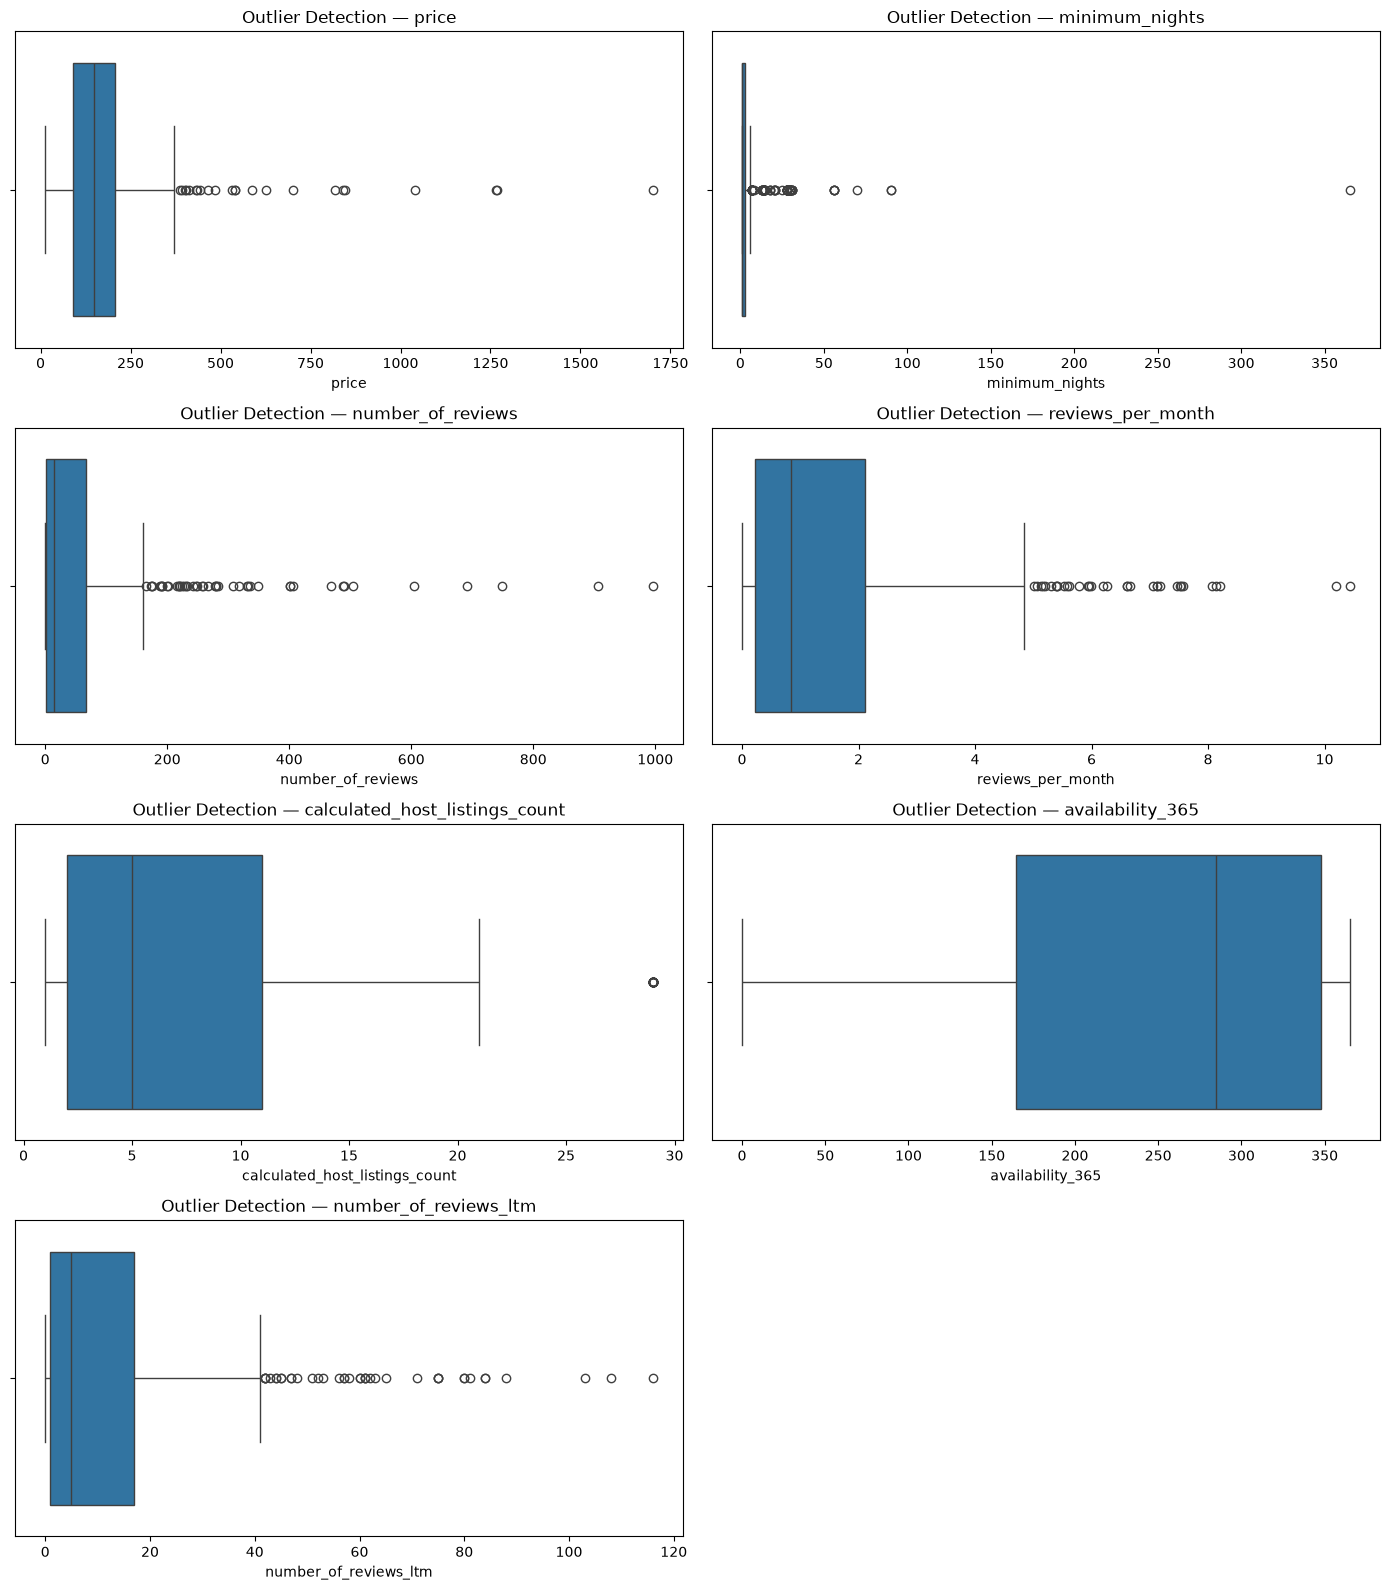

In [8]:
from pathlib import Path

# Boxplots for visual inspection
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Outlier Detection — {col}")
    ax.set_xlabel(col)

for ax in axes[len(outlier_cols):]:
    ax.remove()

plt.tight_layout()
FIG_DIR = Path(r"C:\Users\ankan\Desktop\DS_Project\PYTHON\Data cleaning\Inside Airbnb")
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIG_DIR / "outlier_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
# Business-rule checks
invalid_checks = {
    "price <= 0": int((df["price"] <= 0).sum()),
    "minimum_nights <= 0": int((df["minimum_nights"] <= 0).sum()),
    "availability outside 0-365": int(((df["availability_365"] < 0) | (df["availability_365"] > 365)).sum()),
    "latitude outside -90 to 90": int(((df["latitude"] < -90) | (df["latitude"] > 90)).sum()),
    "longitude outside -180 to 180": int(((df["longitude"] < -180) | (df["longitude"] > 180)).sum())}

display(pd.Series(invalid_checks, name="invalid_records").to_frame())

,invalid_records
price <= 0,0
minimum_nights <= 0,0
availability outside 0-365,0
latitude outside -90 to 90,0
longitude outside -180 to 180,0


Outlier Treatment

In [10]:
# Remove only clearly invalid business-rule records.
before = len(df)

df = df[
    (df["price"] > 0) &
    (df["minimum_nights"] >= 1) &
    (df["availability_365"].between(0, 365)) &
    (df["latitude"].between(-90, 90)) &
    (df["longitude"].between(-180, 180))
].copy()

print(f"Rows removed by business rules: {before - len(df)}")
print("Current shape:", df.shape)

# Keep original price; create a visualization-only capped version.
price_cap = df["price"].quantile(0.99)
df["price_for_viz"] = df["price"].clip(upper=price_cap)

print(f"99th percentile price cap for visualization: {price_cap:,.2f}")

Rows removed by business rules: 0
Current shape: (490, 17)
99th percentile price cap for visualization: 840.66


Data Type Conversion & Validation

In [11]:
# Numeric columns
numeric_cols = [
    "id", "host_id", "host_profile_id", "latitude", "longitude", "price",
    "minimum_nights", "number_of_reviews", "reviews_per_month",
    "calculated_host_listings_count", "availability_365",
    "number_of_reviews_ltm"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Categorical columns
categorical_cols = [
    "neighbourhood", "room_type", "host_name"
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

display(df.dtypes.to_frame("dtype"))

,dtype
id,int64
name,str
host_id,int64
host_profile_id,int64
host_name,category
neighbourhood,category
latitude,float64
longitude,float64
room_type,category
price,float64


Feature Engineering

In [ ]:
df["price_category"] = pd.cut(
    df["price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["Budget", "Standard", "Premium", "Luxury"],
    include_lowest=True)

df["availability_rate"] = (df["availability_365"] / 365) * 100

df["review_activity"] = pd.cut(
    df["reviews_per_month"],
    bins=[-np.inf, 0, 1, 3, np.inf],
    labels=["No Reviews", "Low", "Medium", "High"],
    include_lowest=True)

df["host_type"] = pd.cut(
    df["calculated_host_listings_count"],
    bins=[0, 1, 5, 10, np.inf],
    labels=["Single Property", "Small Host", "Medium Host", "Large Host"],
    include_lowest=True)

df["stay_category"] = pd.cut(
    df["minimum_nights"],
    bins=[0, 2, 7, 30, np.inf],
    labels=["Short Stay", "Weekly Stay", "Monthly Stay", "Long Stay"],
    include_lowest=True)

feature_cols = [
    "price_category", "availability_rate",
    "review_activity", "host_type", "stay_category"]
display(df[feature_cols].head(10))

,price_category,availability_rate,review_activity,host_type,stay_category
0,Budget,21.095890,Low,Single Property,Monthly Stay
1,Standard,89.863014,Medium,Medium Host,Short Stay
2,Budget,6.849315,Medium,Small Host,Short Stay
3,Standard,98.356164,Medium,Medium Host,Short Stay
4,Budget,64.383562,High,Small Host,Short Stay
5,Budget,42.191781,High,Small Host,Short Stay
6,Premium,97.808219,Medium,Medium Host,Short Stay
7,Budget,99.726027,Medium,Small Host,Monthly Stay
8,Budget,72.054795,Low,Small Host,Weekly Stay
9,Premium,87.397260,Medium,Single Property,Short Stay


Final Data Validation

In [13]:
print("Final shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["id"].duplicated().sum())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nNumeric summary:")
display(df.select_dtypes(include=np.number).describe().T)


Final shape: (490, 23)
Duplicate rows: 0
Duplicate IDs: 0

Missing values:


,missing_count
last_review,60
name,0
id,0
host_profile_id,0
host_name,0
neighbourhood,0
host_id,0
latitude,0
longitude,0
price,0



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
id,490.0,9.617549e+17,5.800837e+17,2.992450e+06,6.904915e+17,1.112067e+18,1.458295e+18,1.701483e+18
host_id,490.0,6.840569e+15,1.069623e+17,6.490680e+05,4.762598e+07,2.329679e+08,4.667901e+08,1.676923e+18
host_profile_id,490.0,1.472998e+18,2.819249e+16,1.462518e+18,1.463574e+18,1.468232e+18,1.469754e+18,1.676923e+18
latitude,490.0,4.265878e+01,1.044079e-02,4.263066e+01,4.265278e+01,4.265735e+01,4.266434e+01,4.271490e+01
longitude,490.0,-7.377677e+01,1.818966e-02,-7.387649e+01,-7.378777e+01,-7.377462e+01,-7.376414e+01,-7.373825e+01
price,490.0,1.749531e+02,1.527338e+02,1.300000e+01,9.000000e+01,1.490000e+02,2.055000e+02,1.701000e+03
minimum_nights,490.0,6.832653e+00,1.986222e+01,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00,3.650000e+02
number_of_reviews,490.0,5.927755e+01,1.121910e+02,0.000000e+00,2.000000e+00,1.500000e+01,6.600000e+01,9.960000e+02
reviews_per_month,490.0,1.536061e+00,1.826569e+00,0.000000e+00,2.200000e-01,8.400000e-01,2.107500e+00,1.043000e+01
calculated_host_listings_count,490.0,7.738776e+00,7.717211e+00,1.000000e+00,2.000000e+00,5.000000e+00,1.100000e+01,2.900000e+01


Exploratory Data Analysis (EDA)

In [ ]:
# Core descriptive statistics
eda_summary = pd.DataFrame({
    "metric": [
        "Total Listings",
        "Average Price",
        "Median Price",
        "Average Reviews",
        "Average Minimum Stay",
        "Average Availability (days)",
        "Average Availability (%)",
        "Total Neighbourhoods",
        "Total Hosts"],
    "value": [
        df["id"].nunique(),
        df["price"].mean(),
        df["price"].median(),
        df["number_of_reviews"].mean(),
        df["minimum_nights"].mean(),
        df["availability_365"].mean(),
        df["availability_rate"].mean(),
        df["neighbourhood"].nunique(),
        df["host_id"].nunique()]})

display(eda_summary)


,metric,value
0,Total Listings,490.000000
1,Average Price,174.953061
2,Median Price,149.000000
3,Average Reviews,59.277551
4,Average Minimum Stay,6.832653
5,Average Availability (days),242.893878
6,Average Availability (%),66.546268
7,Total Neighbourhoods,15.000000
8,Total Hosts,186.000000


In [ ]:
# Room type distribution
room_type_summary = (
    df.groupby("room_type", observed=True)
      .agg(
          listings=("id", "nunique"),
          avg_price=("price", "mean"),
          median_price=("price", "median"),
          avg_reviews=("number_of_reviews", "mean"),
          avg_availability=("availability_365", "mean"))
      .sort_values("listings", ascending=False))

display(room_type_summary)


,listings,avg_price,median_price,avg_reviews,avg_availability
room_type,,,,,
Entire home/apt,345,205.701449,166.0,65.133333,252.860870
Private room,135,88.874074,72.0,48.622222,215.162963
Hotel room,9,213.555556,186.0,0.222222,288.111111
Shared room,1,840.000000,840.0,9.000000,141.000000


In [ ]:
# Neighbourhood summary
neighbourhood_summary = (
    df.groupby("neighbourhood", observed=True)
      .agg(
          listings=("id", "nunique"),
          avg_price=("price", "mean"),
          median_price=("price", "median"),
          avg_availability=("availability_365", "mean"),
          avg_reviews=("number_of_reviews", "mean"))
      .sort_values("listings", ascending=False))

display(neighbourhood_summary.head(15))


,listings,avg_price,median_price,avg_availability,avg_reviews
neighbourhood,,,,,
SIXTH WARD,117,163.863248,161.0,257.931624,70.059829
TENTH WARD,56,147.714286,82.5,206.839286,27.267857
THIRD WARD,43,161.558140,133.0,242.302326,31.488372
NINTH WARD,42,158.309524,109.5,237.452381,46.023810
THIRTEENTH WARD,41,182.195122,124.0,206.658537,43.048780
SECOND WARD,41,222.243902,180.0,235.804878,136.951220
ELEVENTH WARD,32,91.750000,89.0,320.593750,30.500000
FOURTEENTH WARD,32,194.125000,105.0,219.656250,91.031250
FOURTH WARD,15,204.733333,195.0,206.666667,66.066667


In [ ]:
# Host summary
host_summary = (
    df.groupby("host_type", observed=True)
      .agg(
          listings=("id", "nunique"),
          avg_price=("price", "mean"),
          median_price=("price", "median"),
          avg_reviews=("number_of_reviews", "mean"),
          avg_availability=("availability_365", "mean"))
      .sort_values("listings", ascending=False))

display(host_summary)


,listings,avg_price,median_price,avg_reviews,avg_availability
host_type,,,,,
Large Host,154,175.616883,137.0,53.246753,238.409091
Small Host,149,153.986577,147.0,68.375839,252.926174
Single Property,107,195.121495,166.0,62.588785,207.299065
Medium Host,80,185.750000,140.5,49.512500,280.450000


In [ ]:
# Correlation matrix for key numerical variables
corr_cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "number_of_reviews_ltm"]

correlation = df[corr_cols].corr()
display(correlation)


,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
price,1.000000,-0.150991,0.000885,0.066037,-0.083335,-0.009318,0.064393
minimum_nights,-0.150991,1.000000,-0.128228,-0.204153,-0.016616,0.019955,-0.181798
number_of_reviews,0.000885,-0.128228,1.000000,0.698444,-0.108649,-0.071093,0.634960
reviews_per_month,0.066037,-0.204153,0.698444,1.000000,-0.135706,-0.036640,0.879759
calculated_host_listings_count,-0.083335,-0.016616,-0.108649,-0.135706,1.000000,0.169799,-0.130236
availability_365,-0.009318,0.019955,-0.071093,-0.036640,0.169799,1.000000,-0.024442
number_of_reviews_ltm,0.064393,-0.181798,0.634960,0.879759,-0.130236,-0.024442,1.000000


Visualizations

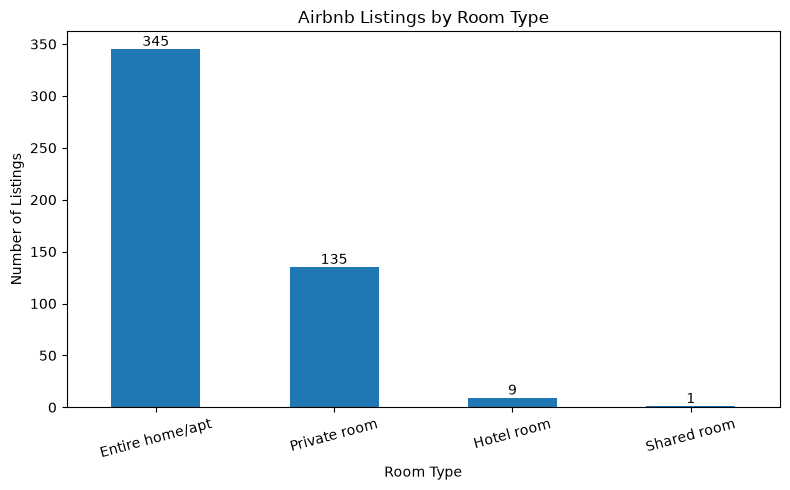

In [ ]:
#Listings by Room Type
room_counts = df["room_type"].astype(str).value_counts()
plt.figure(figsize=(8, 5))
ax = room_counts.plot(kind="bar")
plt.title("Airbnb Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=15)
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.savefig(FIG_DIR / "listings_by_room_type.png", dpi=200, bbox_inches="tight")
plt.show()


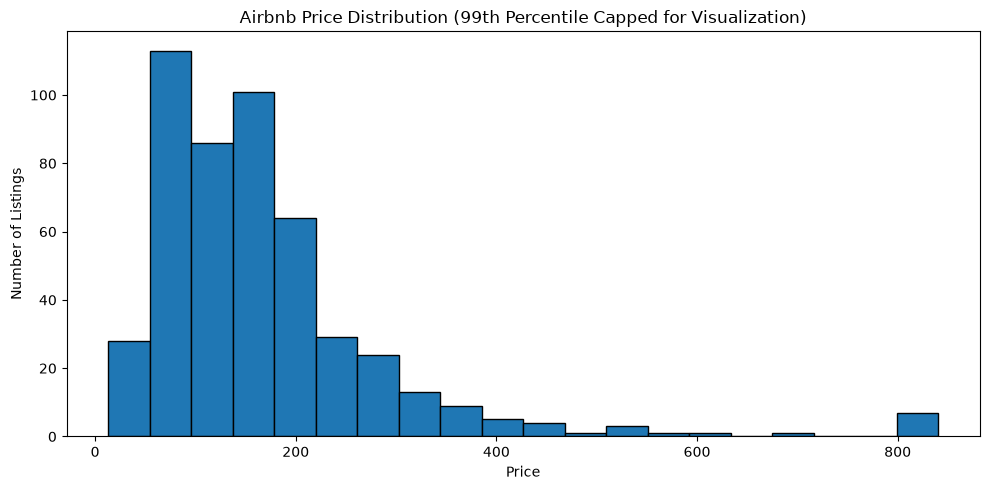

In [ ]:
#Price Distribution
plt.figure(figsize=(10, 5))
plt.hist(df["price_for_viz"], bins=20, edgecolor="black")
plt.title("Airbnb Price Distribution (99th Percentile Capped for Visualization)")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_distribution.png", dpi=200, bbox_inches="tight",edgecolor='black')
plt.show()


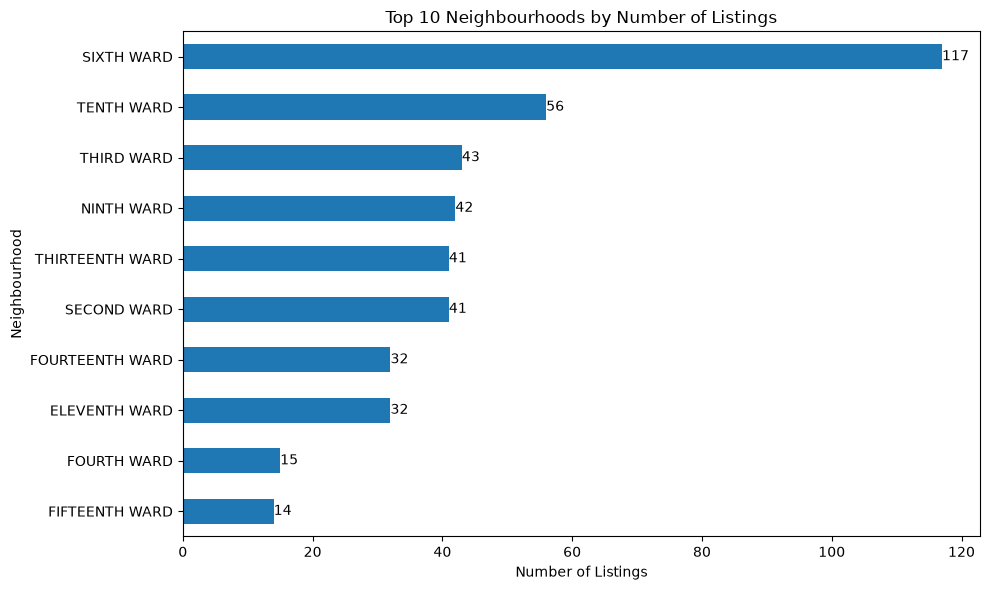

In [ ]:
##Listings by Neighbourhood
top_neighbourhoods = df["neighbourhood"].value_counts().head(10).sort_values()
plt.figure(figsize=(10, 6))
ax = top_neighbourhoods.plot(kind="barh")
plt.title("Top 10 Neighbourhoods by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_neighbourhoods.png", dpi=200, bbox_inches="tight")
plt.show()


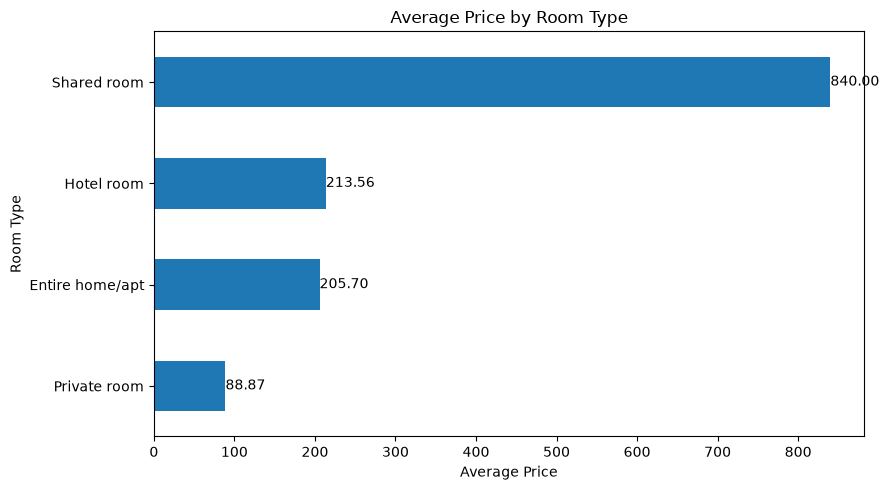

In [ ]:
# Average Price by Room Type
room_price = (
    df.groupby("room_type", observed=True)["price"]
      .mean()
      .sort_values())
plt.figure(figsize=(9, 5))
ax = room_price.plot(kind="barh")
plt.title("Average Price by Room Type")
plt.xlabel("Average Price")
plt.ylabel("Room Type")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()
plt.savefig(FIG_DIR / "average_price_by_room_type.png", dpi=200, bbox_inches="tight")
plt.show()


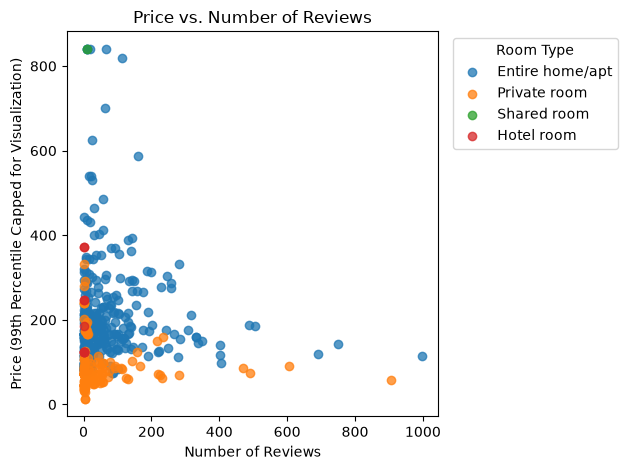

In [ ]:
# Price vs Number of Reviews
plot_df = df.copy()
plot_df["room_type"] = plot_df["room_type"].astype(str)

for room in plot_df["room_type"].dropna().unique():
    subset = plot_df[plot_df["room_type"] == room]
    plt.scatter(
        subset["number_of_reviews"],
        subset["price_for_viz"],
        alpha=0.75,
        label=room)
plt.title("Price vs. Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price (99th Percentile Capped for Visualization)")
plt.legend(title="Room Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "price_vs_reviews.png", dpi=200, bbox_inches="tight")
plt.show()


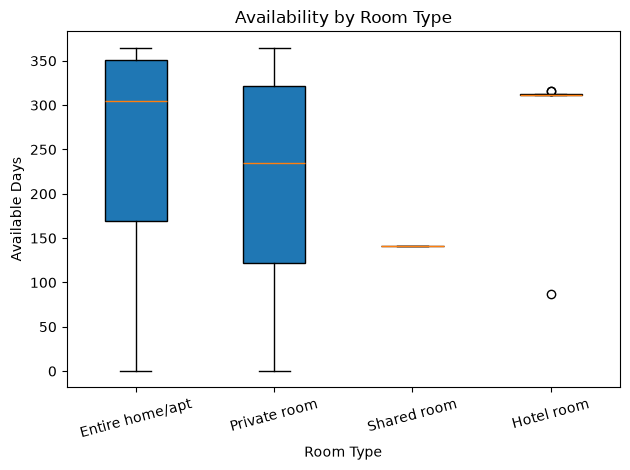

In [ ]:
#Availability by Room Type
room_groups = [
    df.loc[df["room_type"].astype(str) == room, "availability_365"].dropna().values
    for room in df["room_type"].astype(str).unique()]
labels = df["room_type"].astype(str).unique().tolist()
ax = plt.boxplot(room_groups, patch_artist=True)
plt.gca().set_xticklabels(labels)
plt.title("Availability by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Available Days")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / "availability_by_room_type.png", dpi=200, bbox_inches="tight")
plt.show()

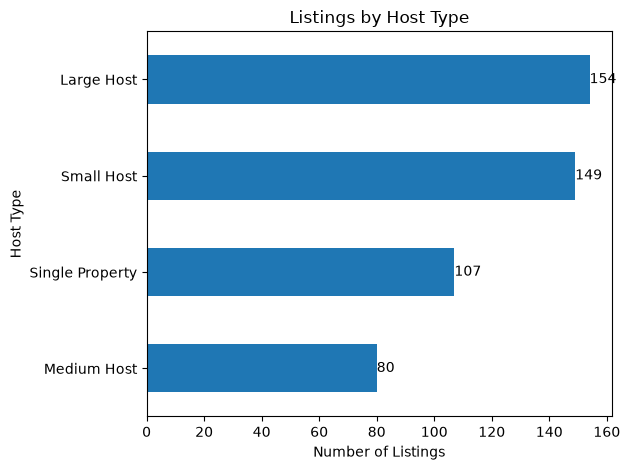

In [ ]:
# Listings by Host Type
host_counts = df["host_type"].value_counts().sort_values()
ax = host_counts.plot(kind="barh")
plt.title("Listings by Host Type")
plt.xlabel("Number of Listings")
plt.ylabel("Host Type")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.tight_layout()
plt.savefig(FIG_DIR / "listings_by_host_type.png", dpi=200, bbox_inches="tight")
plt.show()


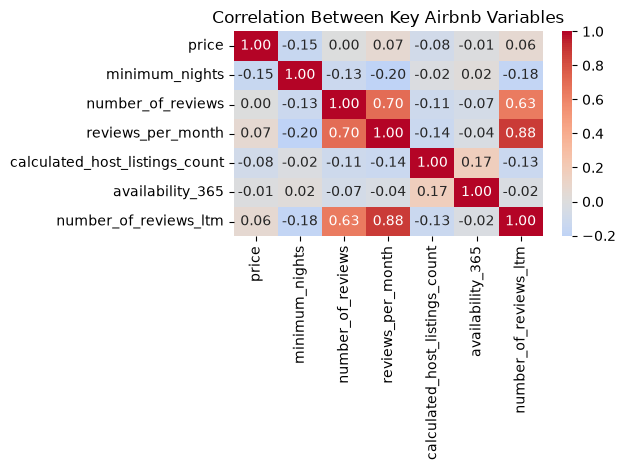

In [ ]:
#Correlation Heatmap
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Key Airbnb Variables")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

Business Insights

In [ ]:
# Automated insight helpers
top_room = room_type_summary.index[0]
top_neighbourhood = neighbourhood_summary.index[0]
highest_avg_price_room = room_type_summary["avg_price"].idxmax()
highest_avg_price_value = room_type_summary["avg_price"].max()

print(f"1. Dominant room type: {top_room} ({room_type_summary.loc[top_room, 'listings']:,} listings).")
print(f"2. Neighbourhood with the most listings: {top_neighbourhood} ({neighbourhood_summary.loc[top_neighbourhood, 'listings']:,} listings).")
print(f"3. Highest average-priced room type: {highest_avg_price_room} ({highest_avg_price_value:,.2f}).")
print(f"4. Overall average price: {df['price'].mean():,.2f}; median price: {df['price'].median():,.2f}.")
print(f"5. Average availability: {df['availability_365'].mean():,.2f} days ({df['availability_rate'].mean():.2f}%).")


1. Dominant room type: Entire home/apt (345 listings).
2. Neighbourhood with the most listings: SIXTH WARD (117 listings).
3. Highest average-priced room type: Shared room (840.00).
4. Overall average price: 174.95; median price: 149.00.
5. Average availability: 242.89 days (66.55%).


## Business Recommendation Framework

After reviewing the results, structure recommendations around:

1. **Pricing:** compare price by neighbourhood and room type; use median price alongside average price because extreme listings can distort the mean.
2. **Location:** investigate high-supply neighbourhoods for competition and less-saturated areas for potential opportunities.
3. **Availability:** unusually high availability may signal opportunities to improve pricing, promotion, or listing visibility.
4. **Reviews:** use review activity as a performance indicator, while avoiding the assumption that reviews alone determine price.
5. **Host strategy:** compare single-property and multi-property hosts to understand differences in price, availability, and review activity.


Export Cleaned Dataset for Power BI

In [ ]:
df.to_csv(r"C:\Users\ankan\Desktop\DS_Project\PYTHON\Data cleaning\Inside Airbnb\Airbnb_Cleaned.csv")
print('Download Complete...')

download complete...
